##  Data Understanding & Cleaning


### Data Loading & Initial Exploration

In [1]:
# Import Libraries
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

In [2]:
# Load Datasets
titles = pd.read_csv('titles.csv')
credits = pd.read_csv('credits.csv')

print(f"titles.csv  -> {titles.shape[0]} rows, {titles.shape[1]} columns")
print(f"credits.csv -> {credits.shape[0]} rows, {credits.shape[1]} columns")

titles.csv  -> 9871 rows, 15 columns
credits.csv -> 124235 rows, 5 columns


In [3]:
# First 10 rows
titles.head(10)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6
5,tm160494,Stagecoach,MOVIE,A group of people traveling on a stagecoach fi...,1939,NaN,96,"['western', 'drama']",['US'],NaN,tt0031971,7.8,48149.0,11.786,7.7
6,tm87233,It's a Wonderful Life,MOVIE,A holiday favourite for generations... George...,1946,PG,130,"['drama', 'family', 'fantasy', 'romance', 'com...",['US'],NaN,tt0038650,8.6,444243.0,26.495,8.3
7,tm19424,Detour,MOVIE,"The life of Al Roberts, a pianist in a New Yor...",1945,NaN,66,"['thriller', 'drama', 'crime']",['US'],NaN,tt0037638,7.3,17233.0,7.757,7.2
8,tm116781,My Man Godfrey,MOVIE,"Fifth Avenue socialite Irene Bullock needs a ""...",1936,NaN,95,"['comedy', 'romance', 'drama']",['US'],NaN,tt0028010,8.0,23532.0,8.633,7.6
9,tm112005,Marihuana,MOVIE,A young girl named Burma attends a beach party...,1936,NaN,57,"['crime', 'drama']",['US'],NaN,tt0026683,4.0,864.0,3.748,3.6


In [4]:
titles.info()

<class 'pandas.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   str    
 1   title                 9871 non-null   str    
 2   type                  9871 non-null   str    
 3   description           9752 non-null   str    
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   str    
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   str    
 8   production_countries  9871 non-null   str    
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   str    
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(2), str(8)


In [5]:
titles.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,9871,9868,tm89134,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,9871,9737,The Lost World,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,9871,2,MOVIE,8514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,9752,9734,No overview found.,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,9871.0,NaN,NaN,NaN,2001.327221,25.810071,1912.0,1995.5,2014.0,2018.0,2022.0
age_certification,3384,11,R,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
runtime,9871.0,NaN,NaN,NaN,85.973052,33.512466,1.0,65.0,89.0,102.0,549.0
genres,9871,2028,['drama'],908,NaN,NaN,NaN,NaN,NaN,NaN,NaN
production_countries,9871,497,['US'],4810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seasons,1357.0,NaN,NaN,NaN,2.791452,4.148958,1.0,1.0,1.0,3.0,51.0


### Data Cleaning

In [6]:
# --- Check missing values ---
missing = titles.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(titles) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})[missing > 0]

,missing_count,missing_pct
seasons,8514,86.25
age_certification,6487,65.72
tmdb_score,2082,21.09
imdb_votes,1031,10.44
imdb_score,1021,10.34
imdb_id,667,6.76
tmdb_popularity,547,5.54
description,119,1.21


In [7]:
# --- Remove exact duplicate rows ---
dup_count = titles.duplicated().sum()
print(f"Exact duplicate rows: {dup_count}")
titles = titles.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {titles.shape}")

Exact duplicate rows: 3
Shape after dropping duplicates: (9868, 15)


In [8]:
# --- Parse stringified list columns into real Python lists ---
def parse_list(val):
    try:
        parsed = ast.literal_eval(val)
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

titles['genres'] = titles['genres'].apply(parse_list)
titles['production_countries'] = titles['production_countries'].apply(parse_list)

titles[['title', 'genres', 'production_countries']].head()

,title,genres,production_countries
0,The Three Stooges,"[comedy, family, animation, action, fantasy, h...",[US]
1,The General,"[action, drama, war, western, comedy, european]",[US]
2,The Best Years of Our Lives,"[romance, war, drama]",[US]
3,His Girl Friday,"[comedy, drama, romance]",[US]
4,In a Lonely Place,"[thriller, drama, romance]",[US]


In [9]:
# --- Standardize text formatting in categorical columns ---
titles['title'] = titles['title'].str.strip()
titles['type'] = titles['type'].str.strip().str.upper()
titles['genres'] = titles['genres'].apply(lambda lst: [g.strip().title() for g in lst])
titles['production_countries'] = titles['production_countries'].apply(
    lambda lst: [c.strip().upper() for c in lst])

print(titles['type'].value_counts())

type
MOVIE    8511
SHOW     1357
Name: count, dtype: int64


In [10]:
# --- Handle remaining missing values ---
# age_certification: missing means genuinely unrated/unknown -> explicit category, not the mode
titles['age_certification'] = titles['age_certification'].fillna('Not Rated')

# description: a handful missing -> fill with placeholder (not used for numeric analysis)
titles['description'] = titles['description'].fillna('No description available')

# seasons: NaN for Movies is structural (not applicable), not missing data -> leave as NaN
# (Movies simply do not have seasons; imputing would be misleading)

# imdb / tmdb score, votes, popularity: leave as NaN for now - these are analyzed with dropna()
# per-plot rather than imputed, to avoid biasing rating distributions with fabricated values

print(titles.isnull().sum())

id                         0
title                      0
type                       0
description                0
release_year               0
age_certification          0
runtime                    0
genres                     0
production_countries       0
seasons                 8511
imdb_id                  667
imdb_score              1021
imdb_votes              1031
tmdb_popularity          547
tmdb_score              2080
dtype: int64


In [11]:
# --- Convert release_year into a datetime-like Period for potential time-based ops ---
titles['release_date'] = pd.to_datetime(titles['release_year'].astype(str) + '-01-01')

titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,release_date
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"[Comedy, Family, Animation, Action, Fantasy, H...",[US],26.0,tt0850645,8.6,1092.0,15.424,7.6,1934-01-01
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Not Rated,78,"[Action, Drama, War, Western, Comedy, European]",[US],NaN,tt0017925,8.2,89766.0,8.647,8.0,1926-01-01
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,Not Rated,171,"[Romance, War, Drama]",[US],NaN,tt0036868,8.1,63026.0,8.435,7.8,1946-01-01
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,Not Rated,92,"[Comedy, Drama, Romance]",[US],NaN,tt0032599,7.8,57835.0,11.270,7.4,1940-01-01
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,Not Rated,94,"[Thriller, Drama, Romance]",[US],NaN,tt0042593,7.9,30924.0,8.273,7.6,1950-01-01


In [12]:
df = titles.copy()  # cleaned working dataframe used throughout the rest of the notebook
print(f"Final cleaned shape: {df.shape}")

Final cleaned shape: (9868, 16)


##  Univariate Analysis

### Content Types

type
MOVIE    8511
SHOW     1357
Name: count, dtype: int64
type
MOVIE    86.2
SHOW     13.8
Name: count, dtype: float64


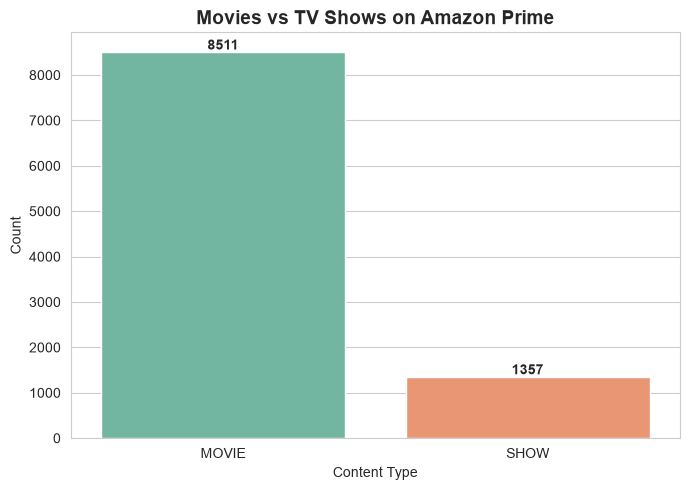

In [13]:
# --- Content Distribution Across The Platform ---
type_counts = df['type'].value_counts()
print(type_counts)
print((type_counts / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index,
            palette='Set2', legend=False, ax=ax)
ax.set_title('Movies vs TV Shows on Amazon Prime', fontsize=14, fontweight='bold')
ax.set_xlabel('Content Type')
ax.set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Release Year

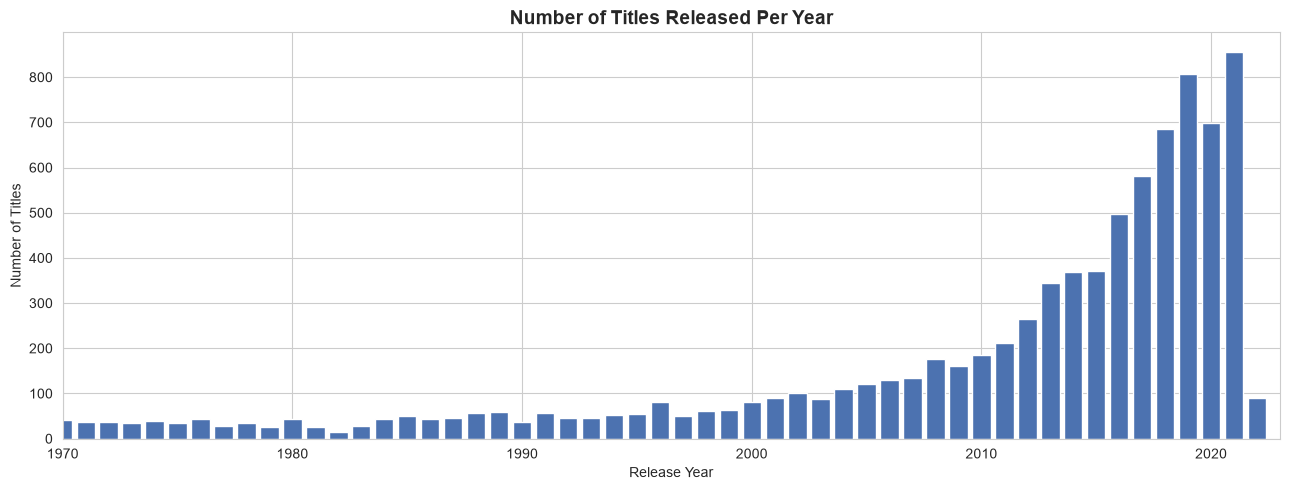

Earliest release year: 1912
Most common release year: 2021 (856 titles)


In [14]:
year_counts = df['release_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(year_counts.index, year_counts.values, color='#4C72B0', width=0.8)
ax.set_title('Number of Titles Released Per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Titles')
ax.set_xlim(1970, 2023)
plt.tight_layout()
plt.show()

print("Earliest release year:", df['release_year'].min())
print("Most common release year:", year_counts.idxmax(), f"({year_counts.max()} titles)")

### Genre Distribution

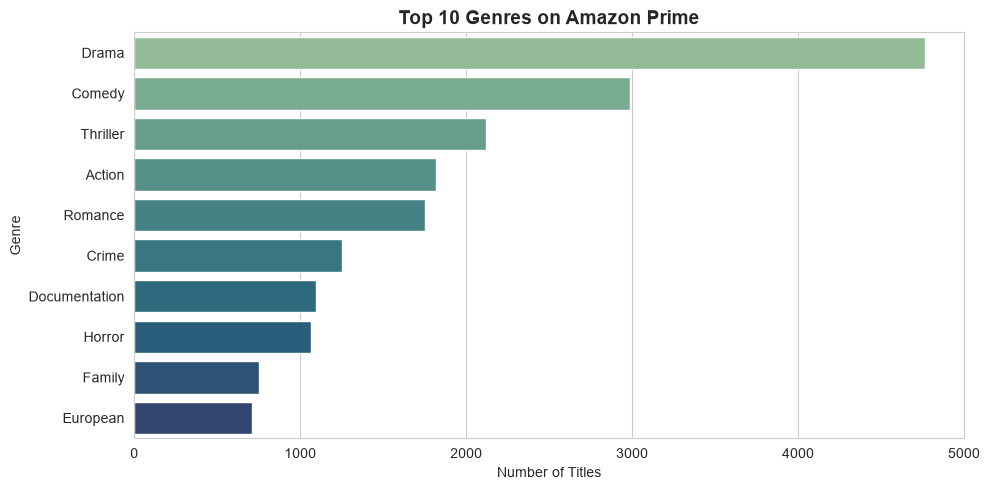

genres
Drama            4762
Comedy           2987
Thriller         2119
Action           1820
Romance          1751
Crime            1250
Documentation    1096
Horror           1065
Family            751
European          712
Name: count, dtype: int64

In [15]:
genre_exploded = df.explode('genres').reset_index(drop=True)
genre_counts = genre_exploded['genres'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index,
            palette='crest', legend=False, ax=ax)
ax.set_title('Top 10 Genres on Amazon Prime', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.show()

genre_counts

### Ratings 

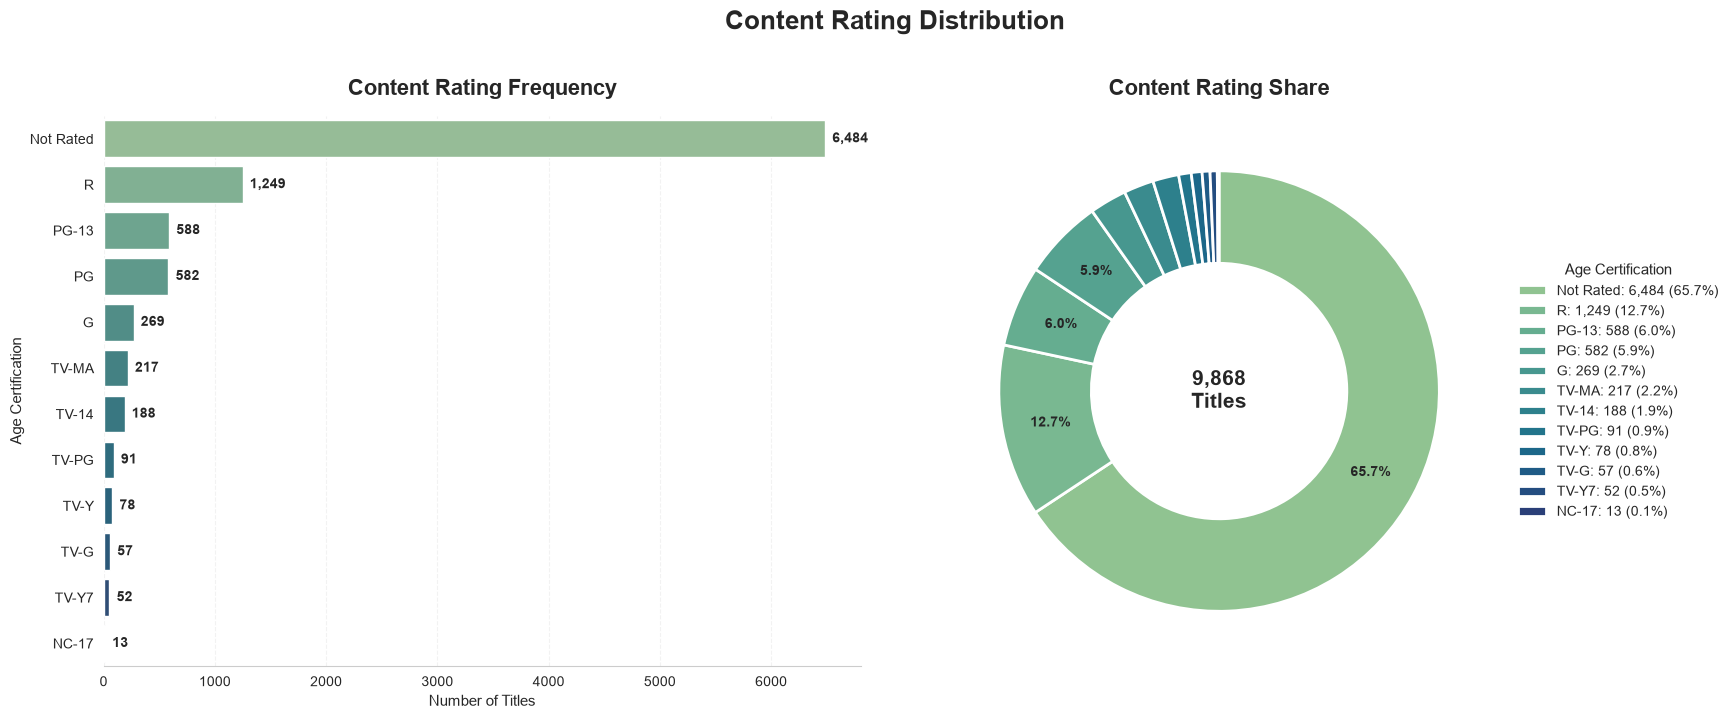

age_certification
Not Rated    6484
R            1249
PG-13         588
PG            582
G             269
TV-MA         217
TV-14         188
TV-PG          91
TV-Y           78
TV-G           57
TV-Y7          52
NC-17          13
Name: count, dtype: int64

In [16]:
rating_counts = df['age_certification'].value_counts()

# Clean modern palette
colors = sns.color_palette("crest", len(rating_counts))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# =========================================================
# 1. BAR CHART - CONTENT RATING FREQUENCY
# =========================================================

bars = sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index,
    hue=rating_counts.index,
    palette=colors,
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    'Content Rating Frequency',
    fontsize=16,
    fontweight='bold',
    pad=15
)

axes[0].set_xlabel('Number of Titles', fontsize=11)
axes[0].set_ylabel('Age Certification', fontsize=11)

# Add values to bars
for bar in bars.patches:
    axes[0].text(
        bar.get_width() + rating_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width()):,}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Grid
axes[0].grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

axes[0].set_axisbelow(True)

# Remove unnecessary borders
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)


# =========================================================
# 2. DONUT CHART - CONTENT RATING SHARE
# =========================================================

def show_percentage(pct):
    # Only display percentage for slices >= 3%
    return f'{pct:.1f}%' if pct >= 3 else ''

wedges, _, autotexts = axes[1].pie(
    rating_counts.values,
    labels=None,                  # Remove overlapping labels
    autopct=show_percentage,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops={
        'width': 0.42,
        'edgecolor': 'white',
        'linewidth': 2
    },
    pctdistance=0.78,
    textprops={
        'fontsize': 10,
        'fontweight': 'bold'
    }
)

axes[1].set_title(
    'Content Rating Share',
    fontsize=16,
    fontweight='bold',
    pad=15
)

# Center text
axes[1].text(
    0,
    0,
    f'{rating_counts.sum():,}\nTitles',
    ha='center',
    va='center',
    fontsize=15,
    fontweight='bold'
)


# =========================================================
# LEGEND
# =========================================================

legend_labels = [
    f'{rating}: {count:,} ({count / rating_counts.sum() * 100:.1f}%)'
    for rating, count in rating_counts.items()
]

axes[1].legend(
    wedges,
    legend_labels,
    title='Age Certification',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)


# =========================================================
# OVERALL TITLE
# =========================================================

fig.suptitle(
    'Content Rating Distribution',
    fontsize=19,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()


# Display counts
rating_counts

## Bivariate Analysis

### Content Type by Rating

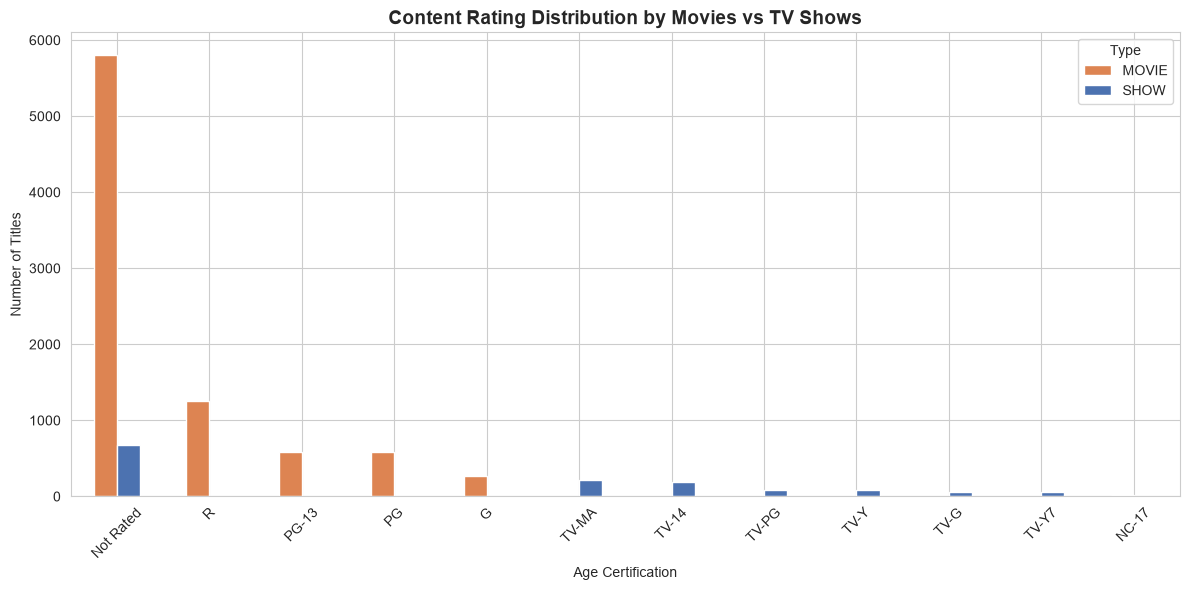

In [17]:
rating_type_ct = pd.crosstab(df['age_certification'], df['type'])
rating_type_ct = rating_type_ct.loc[rating_type_ct.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 6))
rating_type_ct.plot(kind='bar', ax=ax, color=['#DD8452', '#4C72B0'])
ax.set_title('Content Rating Distribution by Movies vs TV Shows', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Certification')
ax.set_ylabel('Number of Titles')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Type')
plt.tight_layout()
plt.show()

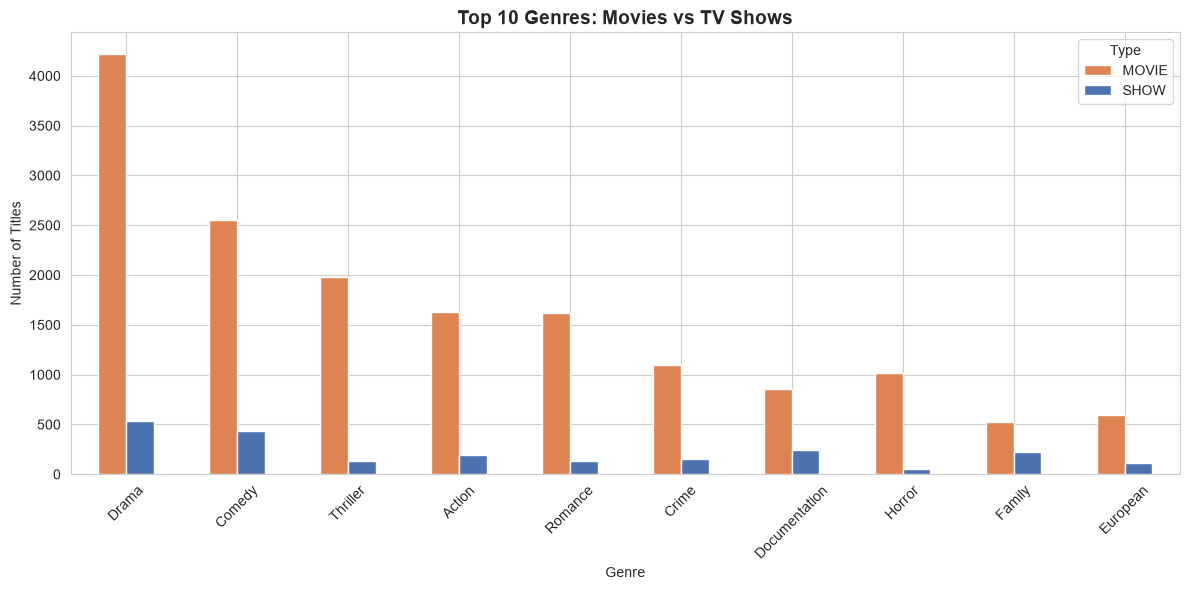

type,MOVIE,SHOW
genres,,
Family,70.4,29.6
Documentation,78.1,21.9
European,83.7,16.3
Comedy,85.6,14.4
Crime,87.6,12.4
Drama,88.7,11.3
Action,89.6,10.4
Romance,92.5,7.5
Thriller,93.7,6.3


In [18]:
genre_type = df.explode('genres').reset_index(drop=True)
genre_type_ct = pd.crosstab(genre_type['genres'], genre_type['type'])
top_genres_list = genre_counts.index  # top 10 genres from Task 5
genre_type_top = genre_type_ct.loc[top_genres_list]

fig, ax = plt.subplots(figsize=(12, 6))
genre_type_top.plot(kind='bar', ax=ax, color=['#DD8452', '#4C72B0'])
ax.set_title('Top 10 Genres: Movies vs TV Shows', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Titles')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Type')
plt.tight_layout()
plt.show()

# Which genres are proportionally more TV-Show-heavy?
genre_type_pct = (genre_type_ct.div(genre_type_ct.sum(axis=1), axis=0) * 100).loc[top_genres_list]
genre_type_pct.round(1).sort_values('SHOW', ascending=False)

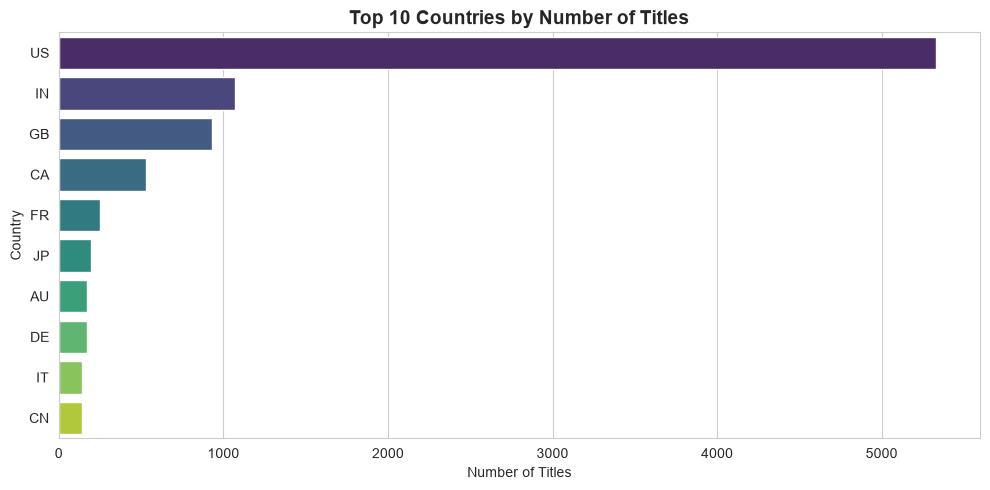

production_countries
US    5331
IN    1072
GB     928
CA     530
FR     250
JP     197
AU     173
DE     172
IT     143
CN     143
Name: count, dtype: int64

In [19]:
country_exploded = df.explode('production_countries').reset_index(drop=True)
top_countries = country_exploded['production_countries'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette='viridis', legend=False, ax=ax)
ax.set_title('Top 10 Countries by Number of Titles', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Country')
plt.tight_layout()
plt.show()

top_countries

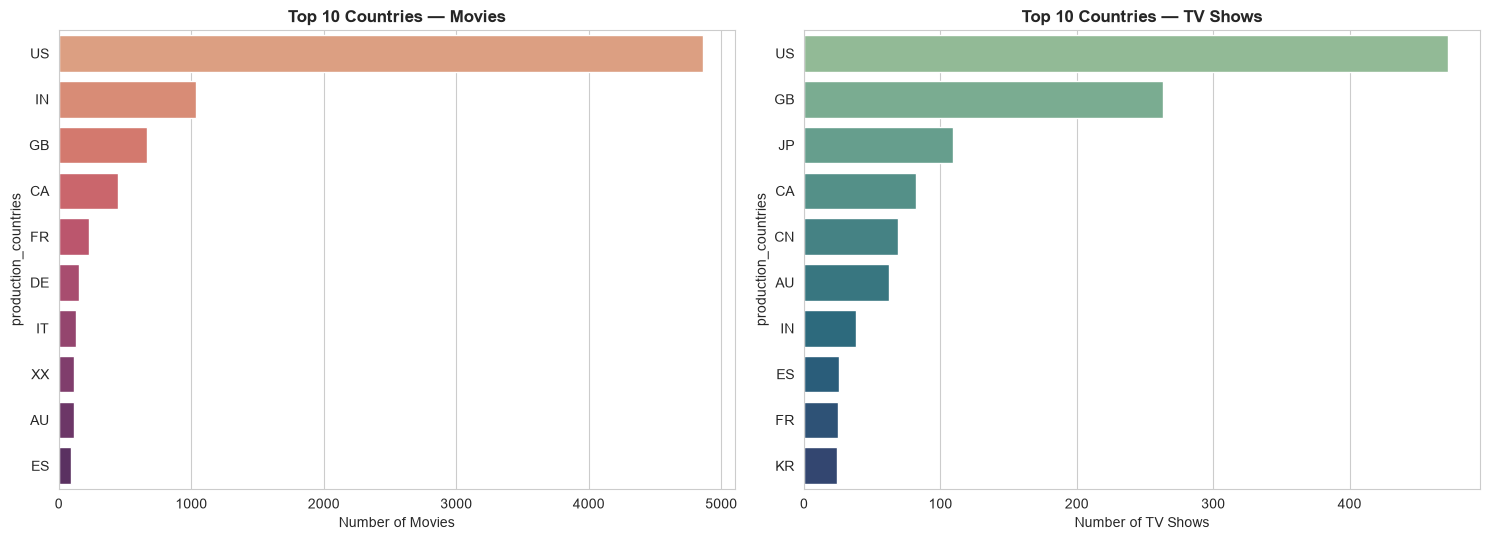

In [20]:
# Filtered by Movies and TV Shows separately
movies_by_country = country_exploded[country_exploded['type'] == 'MOVIE']['production_countries'].value_counts().head(10)
shows_by_country = country_exploded[country_exploded['type'] == 'SHOW']['production_countries'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.barplot(x=movies_by_country.values, y=movies_by_country.index, hue=movies_by_country.index,
            palette='flare', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Countries — Movies', fontweight='bold')
axes[0].set_xlabel('Number of Movies')

sns.barplot(x=shows_by_country.values, y=shows_by_country.index, hue=shows_by_country.index,
            palette='crest', legend=False, ax=axes[1])
axes[1].set_title('Top 10 Countries — TV Shows', fontweight='bold')
axes[1].set_xlabel('Number of TV Shows')

plt.tight_layout()
plt.show()

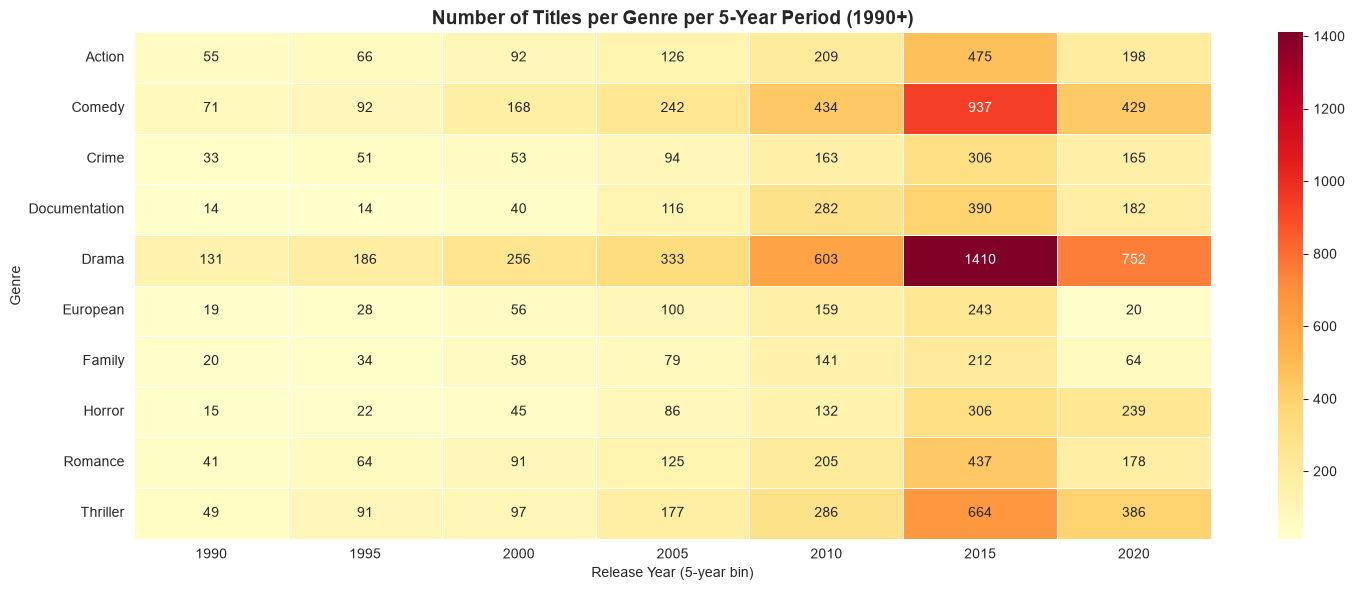

In [21]:
genre_year = df.explode('genres').reset_index(drop=True)
genre_year = genre_year[genre_year['release_year'] >= 1990]  # focus on the modern era for readability

# Bucket years into 5-year bins for a readable heatmap
genre_year['year_bin'] = (genre_year['release_year'] // 5) * 5
top10_genres = genre_counts.index

pivot = genre_year[genre_year['genres'].isin(top10_genres)].pivot_table(
    index='genres', columns='year_bin', values='id', aggfunc='count', fill_value=0
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5, ax=ax)
ax.set_title('Number of Titles per Genre per 5-Year Period (1990+)', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year (5-year bin)')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.show()

## Time-Based Trends

### Content Release Over Time

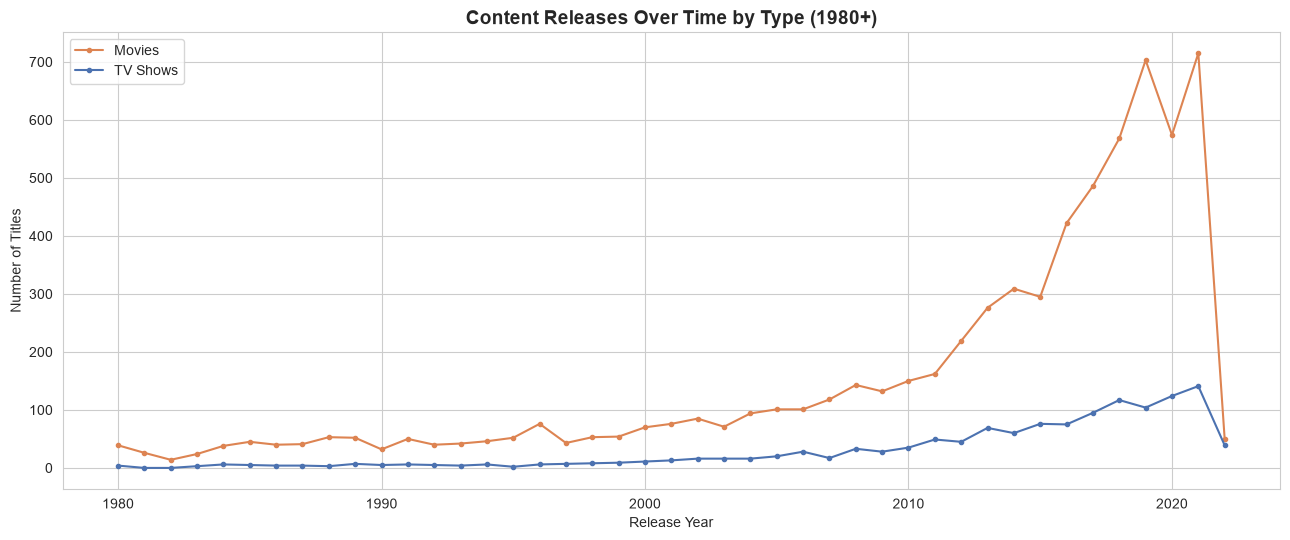

In [22]:
releases_by_type = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)
releases_by_type = releases_by_type[releases_by_type.index >= 1980]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(releases_by_type.index, releases_by_type['MOVIE'], marker='o', markersize=3,
        label='Movies', color='#DD8452')
ax.plot(releases_by_type.index, releases_by_type['SHOW'], marker='o', markersize=3,
        label='TV Shows', color='#4C72B0')
ax.set_title('Content Releases Over Time by Type (1980+)', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Titles')
ax.legend()
plt.tight_layout()
plt.show()

### Rating Trends Over Time

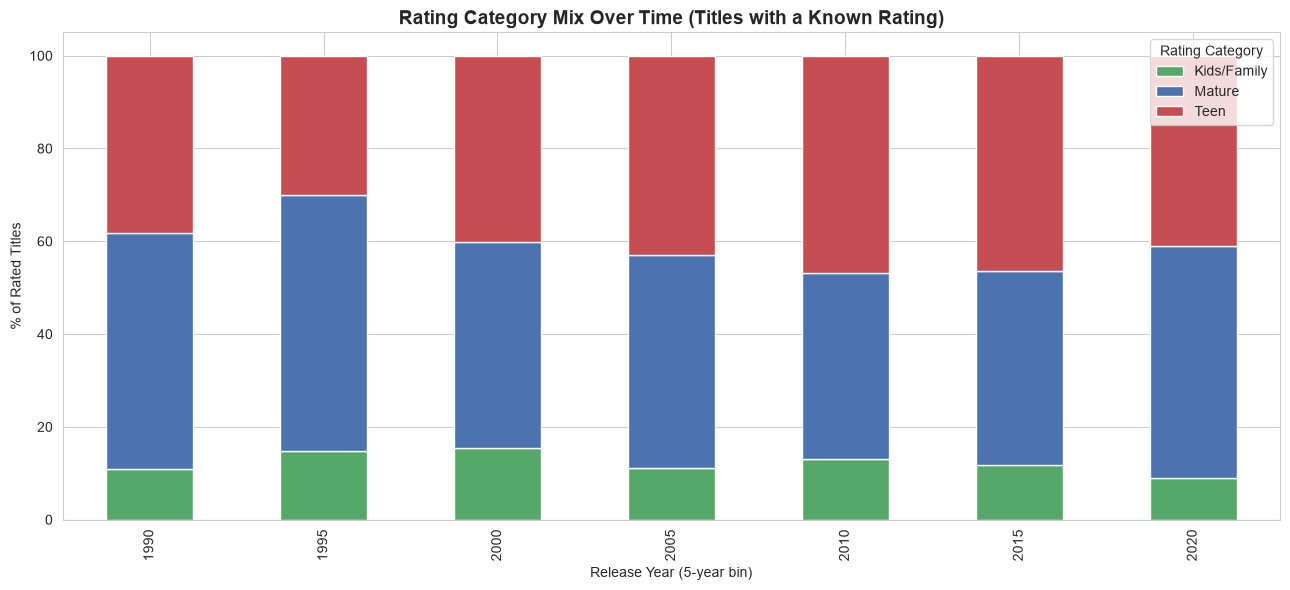

In [23]:
rated = df[df['age_certification'] != 'Not Rated'].copy()
rated['year_bin'] = (rated['release_year'] // 5) * 5
rated = rated[rated['year_bin'] >= 1990]

# Group ratings into simplified buckets for a clearer trend view
def rating_bucket(r):
    kids = {'G', 'TV-G', 'TV-Y', 'TV-Y7'}
    teen = {'PG', 'PG-13', 'TV-PG', 'TV-14'}
    mature = {'R', 'NC-17', 'TV-MA'}
    if r in kids: return 'Kids/Family'
    if r in teen: return 'Teen'
    if r in mature: return 'Mature'
    return 'Other'

rated['rating_bucket'] = rated['age_certification'].apply(rating_bucket)
rating_trend = rated.groupby(['year_bin', 'rating_bucket']).size().unstack(fill_value=0)
rating_trend_pct = rating_trend.div(rating_trend.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
rating_trend_pct.plot(kind='bar', stacked=True, ax=ax,
                       color=['#55A868', '#4C72B0', '#C44E52'])
ax.set_title('Rating Category Mix Over Time (Titles with a Known Rating)', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year (5-year bin)')
ax.set_ylabel('% of Rated Titles')
ax.legend(title='Rating Category')
plt.tight_layout()
plt.show()

## Advanced Grouping & Insights 

### Most Frequent Directors & Actors

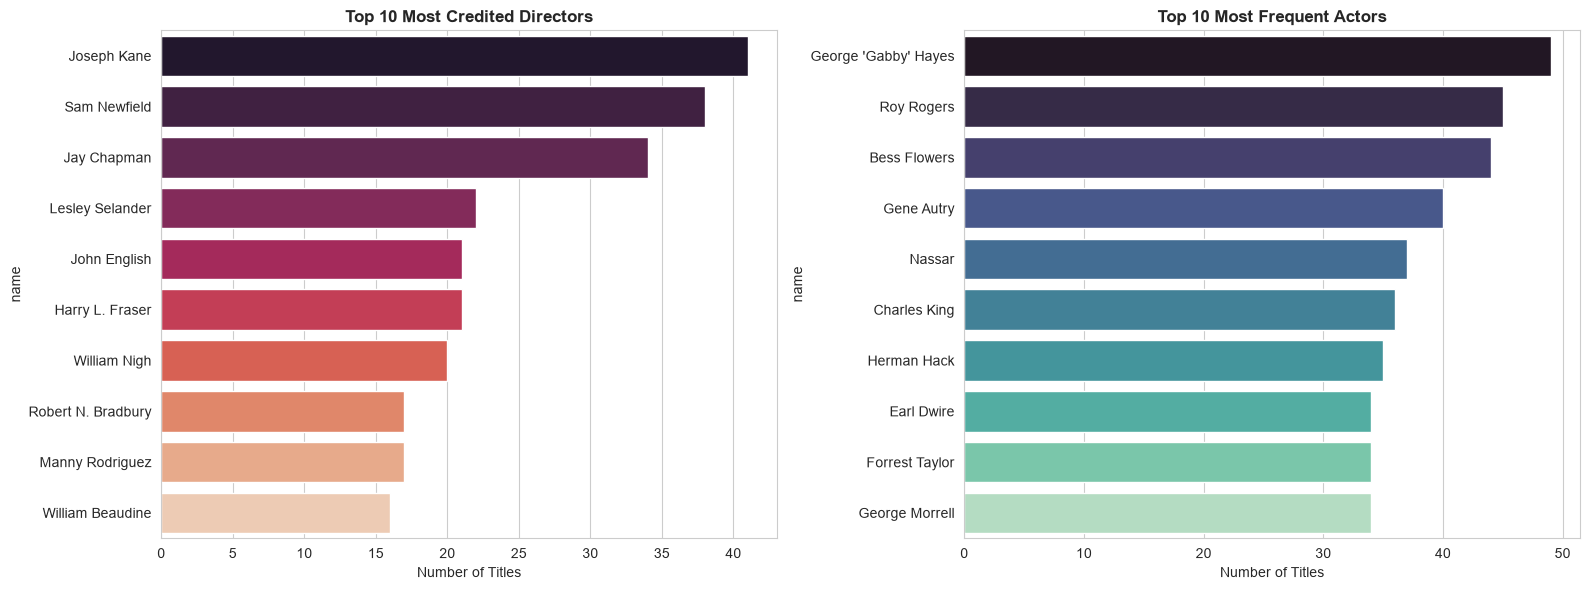

Top Directors:
 name
Joseph Kane           41
Sam Newfield          38
Jay Chapman           34
Lesley Selander       22
John English          21
Harry L. Fraser       21
William Nigh          20
Robert N. Bradbury    17
Manny Rodriguez       17
William Beaudine      16
Name: count, dtype: int64

Top Actors:
 name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Gene Autry              40
Nassar                  37
Charles King            36
Herman Hack             35
Earl Dwire              34
Forrest Taylor          34
George Morrell          34
Name: count, dtype: int64


In [24]:
top_directors = credits[credits['role'] == 'DIRECTOR']['name'].value_counts().head(10)
top_actors = credits[credits['role'] == 'ACTOR']['name'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top_directors.values, y=top_directors.index, hue=top_directors.index,
            palette='rocket', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Most Credited Directors', fontweight='bold')
axes[0].set_xlabel('Number of Titles')

sns.barplot(x=top_actors.values, y=top_actors.index, hue=top_actors.index,
            palette='mako', legend=False, ax=axes[1])
axes[1].set_title('Top 10 Most Frequent Actors', fontweight='bold')
axes[1].set_xlabel('Number of Titles')

plt.tight_layout()
plt.show()

print("Top Directors:\n", top_directors)
print("\nTop Actors:\n", top_actors)

### Contetnt Duration Analysis

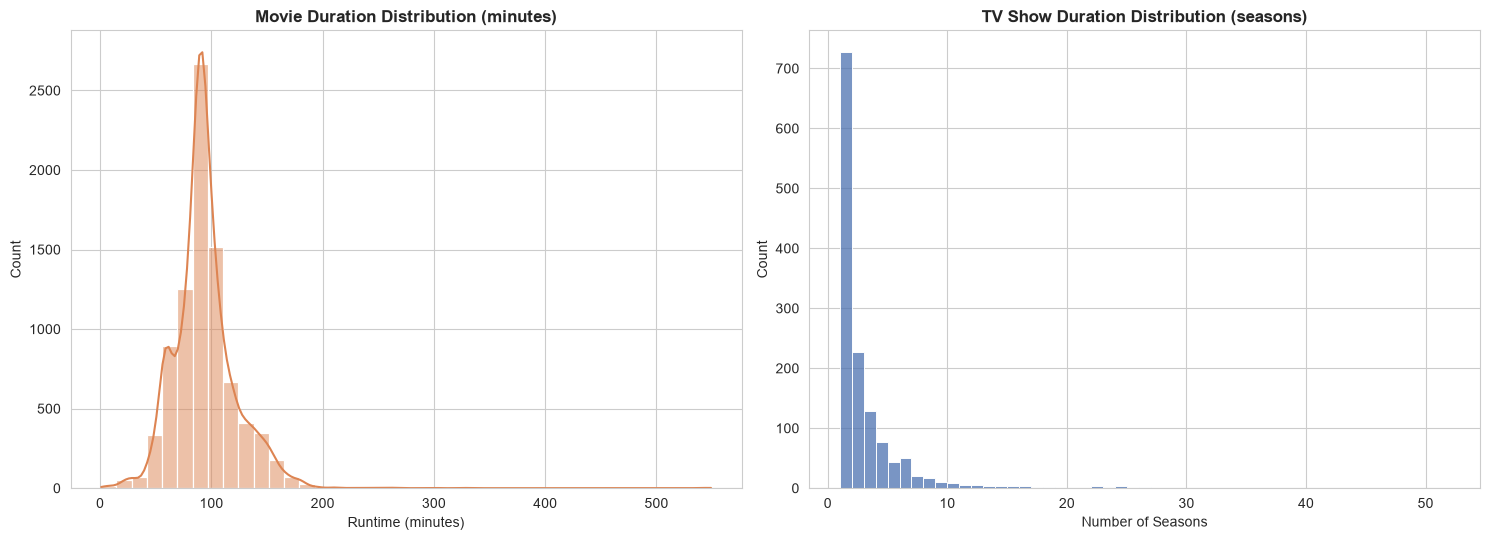

Movie runtime stats:
 count    8511.000000
mean       93.979556
std        28.053207
min         1.000000
25%        80.000000
50%        91.000000
75%       105.000000
max       549.000000
Name: runtime, dtype: float64

TV Show seasons stats:
 count    1357.000000
mean        2.791452
std         4.148958
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        51.000000
Name: seasons, dtype: float64


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

movie_runtime = df[(df['type'] == 'MOVIE') & (df['runtime'] > 0)]['runtime']
sns.histplot(movie_runtime, bins=40, kde=True, color='#DD8452', ax=axes[0])
axes[0].set_title('Movie Duration Distribution (minutes)', fontweight='bold')
axes[0].set_xlabel('Runtime (minutes)')

show_seasons = df[df['type'] == 'SHOW']['seasons'].dropna()
sns.histplot(show_seasons, bins=range(1, int(show_seasons.max()) + 2), color='#4C72B0', ax=axes[1])
axes[1].set_title('TV Show Duration Distribution (seasons)', fontweight='bold')
axes[1].set_xlabel('Number of Seasons')

plt.tight_layout()
plt.show()

print("Movie runtime stats:\n", movie_runtime.describe())
print("\nTV Show seasons stats:\n", show_seasons.describe())

In [26]:
# Outlier check
short_movies = df[(df['type'] == 'MOVIE') & (df['runtime'] < 20) & (df['runtime'] > 0)][['title', 'runtime']]
long_movies = df[(df['type'] == 'MOVIE') & (df['runtime'] > 240)][['title', 'runtime']]
long_shows = df[(df['type'] == 'SHOW') & (df['seasons'] > 20)][['title', 'seasons']]

print(f"Movies under 20 min: {len(short_movies)}")
print(short_movies.sort_values('runtime').head())
print(f"\nMovies over 240 min: {len(long_movies)}")
print(long_movies.sort_values('runtime', ascending=False).head())
print(f"\nShows with more than 20 seasons: {len(long_shows)}")
print(long_shows.sort_values('seasons', ascending=False).head())

Movies under 20 min: 20
                                       title  runtime
2398                               Incognito        1
9028  Evangelion: 3.0+1.0 Thrice Upon a Time        2
6035                              Two Wrongs        4
6078                           Contradiction        5
6074                              Blacksmith        6

Movies over 240 min: 10
                                             title  runtime
5224                                       9 Hours      549
3134                                    Millennium      540
901                            Custer's Last Stand      328
9818  Chhote Ustaad-Precaution Is Better Than Cure      300
5171                                     Superfish      290

Shows with more than 20 seasons: 18
                           title  seasons
1007          Great Performances     51.0
983                         NOVA     49.0
2214                    Survivor     42.0
1851               Home and Away     35.0
1900  The Bold and t

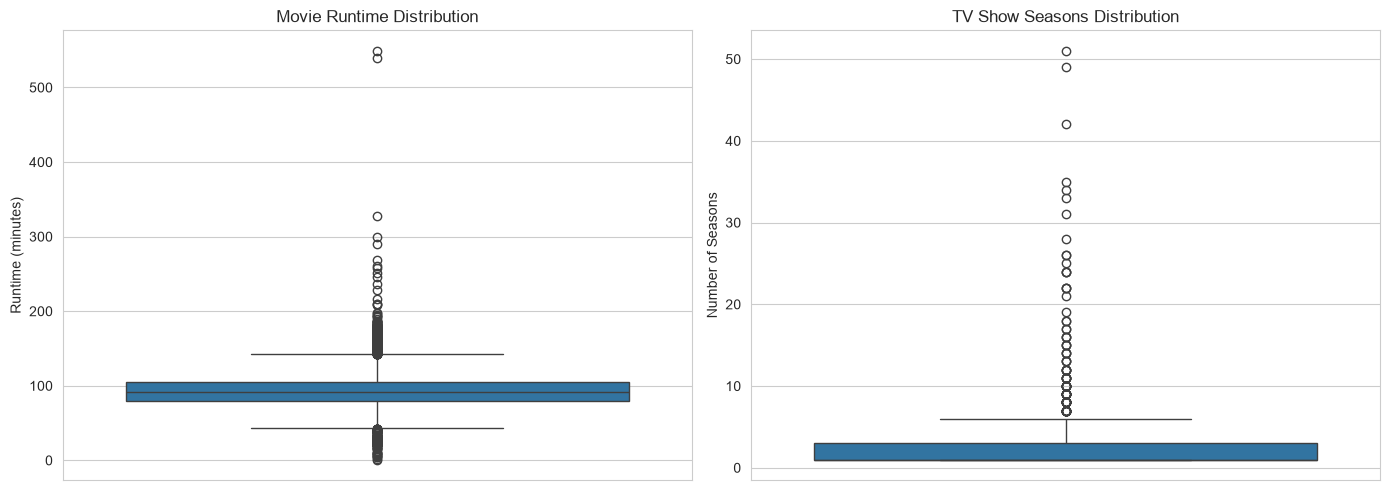

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
movie_runtime = df[(df['type'] == 'MOVIE') & (df['runtime'] > 0)]['runtime']
show_seasons = df[(df['type'] == 'SHOW') & (df['seasons'] > 0)]['seasons']

# Create box plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Movie Runtime
sns.boxplot(y=movie_runtime, ax=axes[0])
axes[0].set_title('Movie Runtime Distribution')
axes[0].set_ylabel('Runtime (minutes)')

# Show Seasons
sns.boxplot(y=show_seasons, ax=axes[1])
axes[1].set_title('TV Show Seasons Distribution')
axes[1].set_ylabel('Number of Seasons')

plt.tight_layout()
plt.show()

### Keyword Analysis in Titles

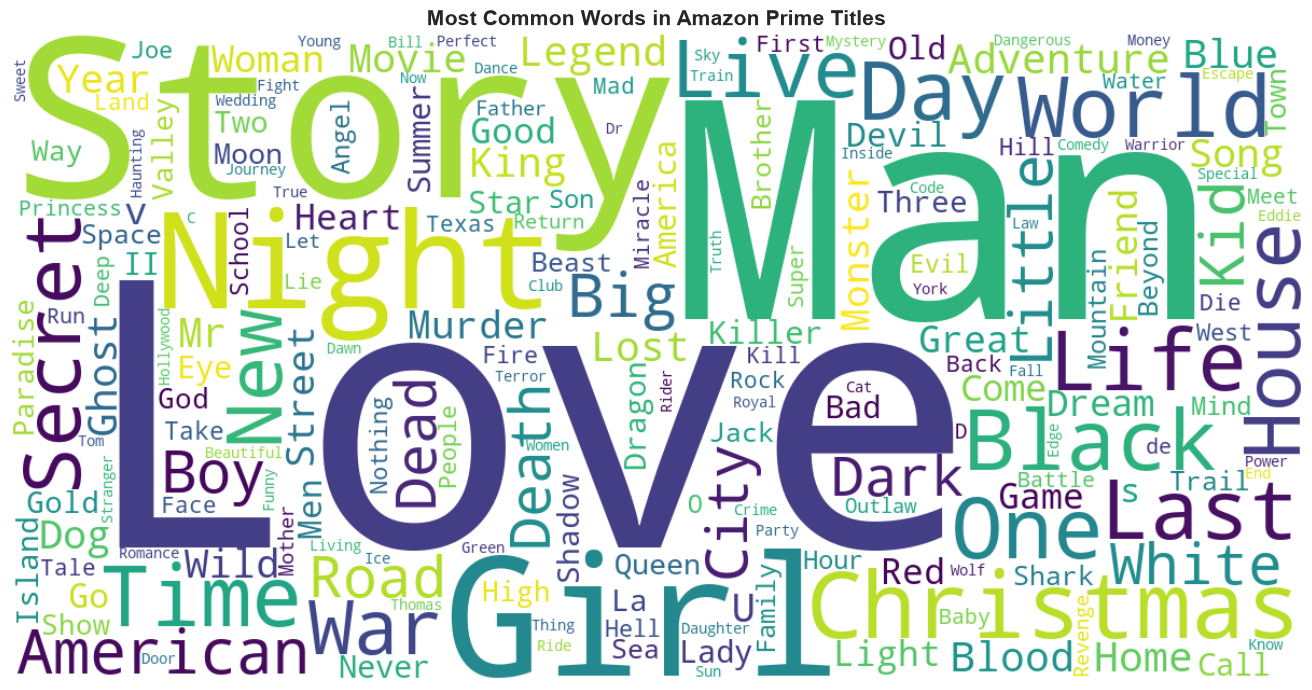

In [28]:
from wordcloud import WordCloud

title_text = ' '.join(df['title'].astype(str).tolist())

wc = WordCloud(width=1200, height=600, background_color='white',
               colormap='viridis', stopwords=None, collocations=False).generate(title_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Words in Amazon Prime Titles', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# Most common genres in titles containing specific keywords
keywords = ['Love', 'War', 'Christmas']

for kw in keywords:
    matches = df[df['title'].str.contains(kw, case=False, na=False)]
    genre_counts_kw = matches.explode('genres').reset_index(drop=True)['genres'].value_counts().head(5)
    print(f"\n--- Titles containing '{kw}' ({len(matches)} titles) — top genres ---")
    print(genre_counts_kw)


--- Titles containing 'Love' (175 titles) — top genres ---
genres
Drama       102
Romance     101
Comedy       77
Thriller     19
Crime        15
Name: count, dtype: int64

--- Titles containing 'War' (113 titles) — top genres ---
genres
Drama            37
Action           30
Comedy           25
Documentation    24
War              18
Name: count, dtype: int64

--- Titles containing 'Christmas' (79 titles) — top genres ---
genres
Comedy     47
Family     36
Romance    34
Drama      27
Fantasy    10
Name: count, dtype: int64


## Predictive Modelling - Predicting Content Type 

In [30]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_df = df.copy()

# Feature engineering
model_df['num_genres'] = model_df['genres'].apply(len)
model_df['num_countries'] = model_df['production_countries'].apply(len)
model_df['primary_genre'] = model_df['genres'].apply(lambda g: g[0] if len(g) > 0 else 'Unknown')
model_df['primary_country'] = model_df['production_countries'].apply(lambda c: c[0] if len(c) > 0 else 'Unknown')

le_genre = LabelEncoder()
le_country = LabelEncoder()
le_rating = LabelEncoder()

model_df['primary_genre_enc'] = le_genre.fit_transform(model_df['primary_genre'])
model_df['primary_country_enc'] = le_country.fit_transform(model_df['primary_country'])
model_df['age_certification_enc'] = le_rating.fit_transform(model_df['age_certification'])

feature_cols = ['release_year', 'runtime', 'num_genres', 'num_countries',
                 'primary_genre_enc', 'primary_country_enc', 'age_certification_enc',
                 'imdb_score', 'tmdb_popularity']

model_data = model_df.dropna(subset=feature_cols).copy()
model_data['target'] = (model_data['type'] == 'SHOW').astype(int)  # 1 = TV Show, 0 = Movie

X = model_data[feature_cols]
y = model_data['target']

print(f"Modeling dataset size: {X.shape[0]} rows")
print(y.value_counts())

Modeling dataset size: 8519 rows
target
0    7433
1    1086
Name: count, dtype: int64


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression baseline
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, log_pred):.3f}")
print(classification_report(y_test, log_pred, target_names=['Movie', 'TV Show']))

print("\n=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.3f}")
print(classification_report(y_test, rf_pred, target_names=['Movie', 'TV Show']))

=== Logistic Regression ===
Accuracy: 0.970
              precision    recall  f1-score   support

       Movie       1.00      0.97      0.98      1487
     TV Show       0.82      0.98      0.89       217

    accuracy                           0.97      1704
   macro avg       0.91      0.97      0.94      1704
weighted avg       0.97      0.97      0.97      1704


=== Random Forest ===
Accuracy: 0.988
              precision    recall  f1-score   support

       Movie       1.00      0.99      0.99      1487
     TV Show       0.93      0.98      0.95       217

    accuracy                           0.99      1704
   macro avg       0.96      0.99      0.97      1704
weighted avg       0.99      0.99      0.99      1704

